# Introduction:
In the `Base_line`notebook I constructed a linear regressor model, `ElasticNet`and `SGDRegressor`, so I can have a starting point and a benchmark comparison of any feature model. As it was shown in that Notebook, linear regression failed to estimate the target variable, `market_forward_excess_returns`. In this Notebook, I will implement a more robust family of models, `RandomForest`and `XGBRegressor`.

In [2]:
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
from dataclasses import dataclass, asdict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings

# Data classes helpers


In [3]:
@dataclass
class DatasetOutput:
    X_train: pl.DataFrame
    X_test: pl.DataFrame
    y_train: pl.Series
    y_test: pl.Series
    scaler: StandardScaler
    scaled: bool

    def __post_init__(self):
        '''Validates that each field holds the expected type, and that
        train/test splits are internally consistent.'''

        # --- type checks ---
        if not isinstance(self.X_train, pl.DataFrame):
            raise TypeError(
                f"X_train must be pl.DataFrame, got {type(self.X_train)}"
            )
        if not isinstance(self.X_test, pl.DataFrame):
            raise TypeError(
                f"X_test must be pl.DataFrame, got {type(self.X_test)}"
            )
        if not isinstance(self.y_train, pl.Series):
            raise TypeError(
                f"y_train must be pl.Series, got {type(self.y_train)}"
            )
        if not isinstance(self.y_test, pl.Series):
            raise TypeError(
                f"y_test must be pl.Series, got {type(self.y_test)}"
            )
        if not isinstance(self.scaler, StandardScaler):
            raise TypeError(
                f"scaler must be sklearn StandardScaler, got {type(self.scaler)}"
            )

        # --- shape / consistency checks ---
        if self.X_train.height != len(self.y_train):
            raise ValueError(
                f"X_train has {self.X_train.height} rows but y_train has "
                f"{len(self.y_train)} entries"
            )
        if self.X_test.height != len(self.y_test):
            raise ValueError(
                f"X_test has {self.X_test.height} rows but y_test has "
                f"{len(self.y_test)} entries"
            )
        if self.X_train.columns != self.X_test.columns:
            raise ValueError(
                f"X_train and X_test have mismatched columns: "
                f"{self.X_train.columns} vs {self.X_test.columns}"
            )

        # --- emptiness checks ---
        if self.X_train.height == 0:
            raise ValueError("X_train is empty")
        if self.X_test.height == 0:
            raise ValueError("X_test is empty")

        # --- scaler fitted check ---
        # A fitted StandardScaler has learned attributes ending in "_"
        # (mean_, scale_, var_). If they're absent, .fit() was never called.
        if not hasattr(self.scaler, "mean_"):
            warnings.warn(
                "scaler has not been fitted (missing 'mean_' attribute) — "
                "call scaler.fit(X_train) before constructing DatasetOutput"
            )

# Function helpers

In [4]:
def load_set(target_variable: str, file_name : str, n_exclude : int,
             shift_train_target: bool = False,) -> pl.DataFrame:
    """
    Loads and preprocesses the training dataset.
    Inputs:
    target_variable (str): variable that is the target of the predictions
    file_name (str) : the name of the file to be loaded
    n_exclude (int) : exclude the n last rows
    shift_train_target (bool): if True, shifts the target column up by
            one row, so that features at row t align with the target's
            value at row t+1, matching the feature/target alignment
            convention used in the test set. Defaults to False.
    
    Returns:
        pl.DataFrame: The preprocessed training DataFrame.
    """

    df = (pl.read_csv(DATA_PATH / file_name)
        .rename({target_variable:'target'})
        .with_columns(
            pl.exclude('date_id').cast(pl.Float64, strict=False) #cast to Float64 all columns except date
        )
        )
    total_exclude = max(n_exclude, 0)
    
    if shift_train_target:
        df = df.with_columns(pl.col("target").shift(-1).alias("target"))
        # the shift leaves the last row's target as null (no t+1 available);
        # fold that into the trailing-row exclusion so it's always dropped
        total_exclude += 1
        
    if total_exclude > 0:
        df = df.head(-total_exclude)
    return (df)


def split_dataset(train: pl.DataFrame, test: pl.DataFrame, features: list[str],
                 standard_scaler_bool: bool) -> DatasetOutput: 
    """
    Splits the data into features (X) and target (y), and scales the features.

    Args:
        train (pl.DataFrame): The processed training DataFrame.
        test (pl.DataFrame): The processed testing DataFrame.
        features (list[str]): List of features to used in model. 
        standard_scaler_bool (bool): Whether or not standard scaler is applied to the data.

    Returns:
        DatasetOutput: A dataclass containing the scaled feature sets, target series, and the fitted scaler.
    """
    # ========== For both, train and test, it drops date_id and target for the X features ===========
    # ========= and takes "target" for the Y (prediction) ===========================================
    X_train = train.drop(['date_id','target']) 
    y_train = train.get_column('target')
    
    X_test = test.drop(['date_id','target']) 
    y_test = test.get_column('target')

    if standard_scaler_bool:
        scaler = StandardScaler() 
        
        X_train_scaled_np = scaler.fit_transform(X_train)
        X_train = pl.from_numpy(X_train_scaled_np, schema=features)
        
        X_test_scaled_np = scaler.transform(X_test)
        X_test = pl.from_numpy(X_test_scaled_np, schema=features)
    else:
        scaler = StandardScaler() 
    
    
    return DatasetOutput(
        X_train = X_train,
        y_train = y_train, 
        X_test = X_test, 
        y_test = y_test,
        scaler = scaler,
        scaled = standard_scaler_bool,
    )

# Read input data

In [5]:
DATA_PATH = Path("/kaggle/input/notebooks/sebastianvpal/data-exploration")
path_train = ("train_split.csv")
path_test = ("test_split.csv")
path_val = ("val_split.csv")

# ============ Reading data
target_variable_training = 'market_forward_excess_returns'
target_variable_test_val = 'lagged_forward_returns'
#===========
ds_train = load_set(target_variable=target_variable_training, 
                    file_name = path_train, n_exclude = 10, shift_train_target=True)
                        # align features(t) -> target(t+1), matching test set) 
#===========
ds_test = load_set(target_variable=target_variable_test_val, 
                    file_name = path_test, n_exclude=0) 
#===========
ds_val = load_set(target_variable=target_variable_test_val, 
                    file_name = path_val, n_exclude=0) 

According to the official documentation forward_returns and risk_free_rateare not available for the test dataset (train set only) I will drop these columns for the moment.

In [6]:
features_to_drop_train = ["forward_returns", "risk_free_rate"]
features_to_drop_test_val = ["lagged_risk_free_rate", "lagged_market_forward_excess_returns"]

ds_train = ds_train.drop(features_to_drop_train)
ds_test = ds_test.drop(features_to_drop_test_val)
ds_val = ds_val.drop(features_to_drop_test_val)

# Generating training and test dataset

In [7]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# creating the dataset. This data will be used for RandomForest, so standardscaler is NOT needed
dataset: DatasetOutput = split_dataset(train=ds_train, test=ds_test, features=FEATURES,
                                      standard_scaler_bool= False) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

/tmp/ipykernel_58/1883765255.py:63: UserWarning: scaler has not been fitted (missing 'mean_' attribute) — call scaler.fit(X_train) before constructing DatasetOutput
  warnings.warn(


In [8]:
print(f"values were scaled: {scaled}")

values were scaled: False


**Given the amount of missing value and its position in the dataset (check data_exploration notebook) I will do imputation of the missing values adding a 0 and a new column 1:real data, 0: artificial, so the model can also distinguish from a real or imputed 0. This is also relevant for RandomForest as it doesn't manage NaN values natively**

In [9]:
imputer = SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Implementing RandomForestRegressor with Randomized search CV

In [10]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint

In [11]:
@dataclass
class RandomForestCV_params():
    max_depth : np.ndarray #max depth of the forest
    min_samples_leaf: np.ndarray #minimum number of samples a leaf can have
    max_features: np.ndarray #how features are split each time
    n_estimators: np.ndarray #how many trees are considered

In [12]:
rng = np.random.default_rng()

RF_params = RandomForestCV_params(
    max_depth = randint(3, 12),
    min_samples_leaf = randint(10, 200),
    max_features = np.array(["sqrt", "log2", 0.3, 0.5], dtype=object),
    n_estimators = np.array([300, 500, 800]),
)

# == creating the RandomForest
rdf = RandomForestRegressor(oob_score=True, n_jobs=-1, random_state=0)# Check the final model using
#the out-of-Bag (OOB) samples using all available cores (n_jobs=-1)

# ===== As my data is a timeseries it is important to avoid any leakage during this search
# ==== for that, I will implement cross validation with awarness of this
time_cv = TimeSeriesSplit(n_splits=5)

# === Searching for the optimal values
RF_search = RandomizedSearchCV(
    rdf,
    param_distributions=asdict(RF_params),
    n_iter=30,
    cv=time_cv,
    scoring="r2",
    random_state=0,
    n_jobs=-1,
)   


RF_search.fit(X_train,y_train)

print("Best params:", RF_search.best_params_)
print("Best CV R²:", RF_search.best_score_)
print("OOB R² of refit best model:", RF_search.best_estimator_.oob_score_)

Best params: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 173, 'n_estimators': np.int64(300)}
Best CV R²: -0.00311977805262349
OOB R² of refit best model: -0.0015618163192427925


# Evaluating the model predictions

In [14]:
# ========== Defining the randomforest with the best combination of parameters 
best_rf = RF_search.best_estimator_

y_pred = best_rf.predict(X_test) #Making predictions

# Evaluating predictions
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test, y_pred)


print("==============================================")
print(f"Test R²:   {r2:.4f}")
print("==============================================")
print(f"max(y_pred): {y_pred.max():.6f}")
print(f"max(y_test): {y_test.max():.6f}")
print("==============================================")
print(f"min(y_pred): {y_pred.min():.6f}")
print(f"min(y_test): {y_test.min():.6f}")
print("==============================================")
print(f"Test RMSE: {rmse:.4f}")
print("==============================================")
print(f"Test MAE:  {mae:.4f}")

Test R²:   -0.0239
max(y_pred): 0.001312
max(y_test): 0.040661
min(y_pred): -0.000563
min(y_test): -0.039754
Test RMSE: 0.0106
Test MAE:  0.0077


In [33]:
importances = best_rf.feature_importances_
feature_names_out = imputer.get_feature_names_out(FEATURES)


feat_imp = (
    pl.DataFrame({"feature": feature_names_out, "importance": importances})
    .sort("importance", descending=True)
)
print("*"*15, " Most important variables","*"*15 )
print(feat_imp[:40])

***************  Most important variables ***************
shape: (40, 2)
┌─────────┬────────────┐
│ feature ┆ importance │
│ ---     ┆ ---        │
│ str     ┆ f64        │
╞═════════╪════════════╡
│ V13     ┆ 0.039138   │
│ S5      ┆ 0.036802   │
│ M4      ┆ 0.033188   │
│ V7      ┆ 0.030748   │
│ S2      ┆ 0.028444   │
│ …       ┆ …          │
│ I5      ┆ 0.011351   │
│ V9      ┆ 0.011322   │
│ P4      ┆ 0.011064   │
│ E10     ┆ 0.011017   │
│ E17     ┆ 0.010579   │
└─────────┴────────────┘


In [34]:
feat_imp_asc = (
    pl.DataFrame({"feature": feature_names_out, "importance": importances})
    .sort("importance", descending=False)
)
print("*"*15, " Less important variables","*"*15 )
print(feat_imp_asc[:90])

***************  Less important variables ***************
shape: (90, 2)
┌──────────────────────┬────────────┐
│ feature              ┆ importance │
│ ---                  ┆ ---        │
│ str                  ┆ f64        │
╞══════════════════════╪════════════╡
│ D1                   ┆ 0.0        │
│ D2                   ┆ 0.0        │
│ D7                   ┆ 0.0        │
│ E7                   ┆ 0.0        │
│ missingindicator_E10 ┆ 0.0        │
│ …                    ┆ …          │
│ M6                   ┆ 0.000632   │
│ missingindicator_V9  ┆ 0.000758   │
│ missingindicator_M2  ┆ 0.000766   │
│ D6                   ┆ 0.000831   │
│ M13                  ┆ 0.000838   │
└──────────────────────┴────────────┘


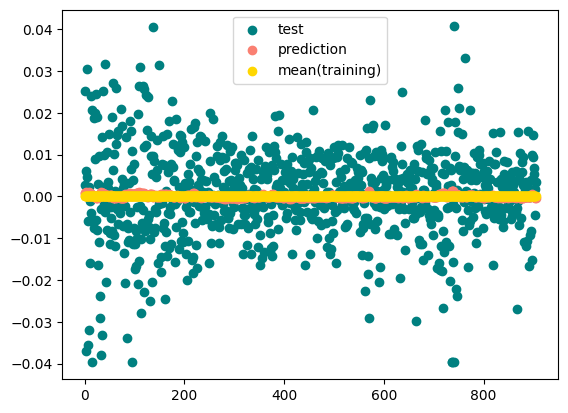

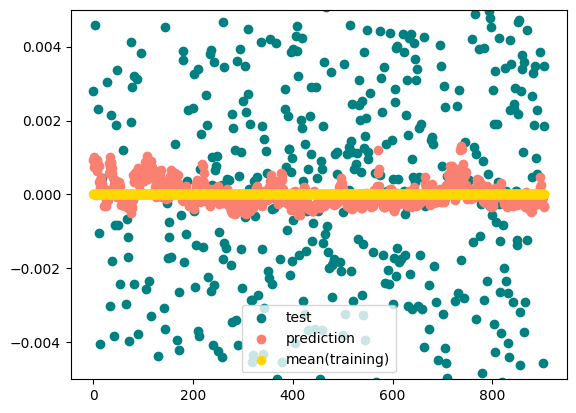

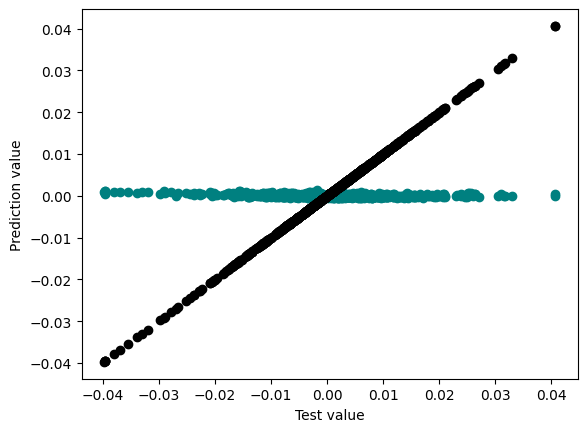

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
naive_pred = np.full_like(y_test, fill_value=y_train.mean())

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')

plt.legend()
plt.show()
#============ plot with zoom =============0
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')
ax.set_ylim(-0.005,0.005)
plt.legend()
plt.show()
# ============= Plot prediciton vs true
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter( y_test, y_pred, color = 'teal')
ax.scatter( y_test, y_test, color = 'black')
ax.set_xlabel("Test value")
ax.set_ylabel("Prediction value")
plt.show()

# Implementation of HistGradientBosstingRegressor

X_train and X_test are computed again because for `HistGradientBoostingRegresso` is not necessary to do imputation. The model handles automatically `NaN`values. This is becuase the model constructs a histogram of the data (256 bins) so instead of splitting the trees with actual values, it splits the data using the histogram. This has the advantage of a faster performance and NaN handling

In [44]:
from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [45]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# creating the dataset. This data will be used for RandomForest, so standardscaler is NOT needed
dataset: DatasetOutput = split_dataset(train=ds_train, test=ds_test, features=FEATURES,
                                      standard_scaler_bool= False) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

/tmp/ipykernel_58/1883765255.py:63: UserWarning: scaler has not been fitted (missing 'mean_' attribute) — call scaler.fit(X_train) before constructing DatasetOutput
  warnings.warn(


In [46]:
@dataclass
class HGBCV_params:
    max_depth: object          # distribution or array of candidate max_depth values
    min_samples_leaf: object   # distribution or array of candidate min_samples_leaf values
    max_leaf_nodes: object     # distribution or array of candidate max_leaf_nodes values
    learning_rate: object      # distribution or array of candidate learning_rate values
    max_iter: object        

In [47]:


   # array of candidate boosting-round counts

rng = np.random.default_rng()

HGB_params = HGBCV_params(
    max_depth=randint(3, 8),                 # shallower than RF — boosting fits residuals
    min_samples_leaf=randint(10, 200),
    max_leaf_nodes=randint(15, 63),           # HGBR's default is 31 — search around it
    learning_rate=uniform(0.01, 0.29),        # uniform(loc, scale) -> range [0.01, 0.30]
    max_iter=np.array([100, 300, 500]),       # replaces RF's n_estimators
)

# == creating the HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor(
    early_stopping=True,      # internally holds out validation data, stops adding trees
                               # once performance plateaus — a boosting-specific safeguard
    random_state=0,
)
# Note: no n_jobs / oob_score here — HGBR doesn't expose either;
# it parallelizes internally via OpenMP without an n_jobs knob, and has no OOB
# mechanism since it doesn't bootstrap (see explanation above).

# ===== As my data is a time series, avoid leakage during this search
time_cv = TimeSeriesSplit(n_splits=5)

# === Searching for the optimal values
HGB_search = RandomizedSearchCV(
    hgb,
    param_distributions=asdict(HGB_params),
    n_iter=30,
    cv=time_cv,
    scoring="r2",
    random_state=0,
    n_jobs=-1,   # parallelizes across the 30 x 5 = 150 CV fits, fine to keep here
)

HGB_search.fit(X_train, y_train)

print("Best params:", HGB_search.best_params_)
print("Best CV R² during CV:", HGB_search.best_score_)

# no OOB equivalent — instead, evaluate directly on the held-out test set
best_hgb = HGB_search.best_estimator_
test_r2 = best_hgb.score(X_test, y_test)
print("Test R² of best model on test set:", test_r2)

Best params: {'learning_rate': np.float64(0.015449042126542991), 'max_depth': 3, 'max_iter': np.int64(100), 'max_leaf_nodes': 32, 'min_samples_leaf': 89}
Best CV R²: -0.0032642403557556765
Test R² of refit best model: -0.005944722258954149


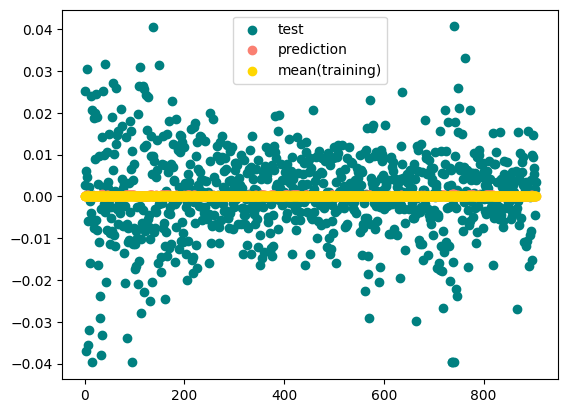

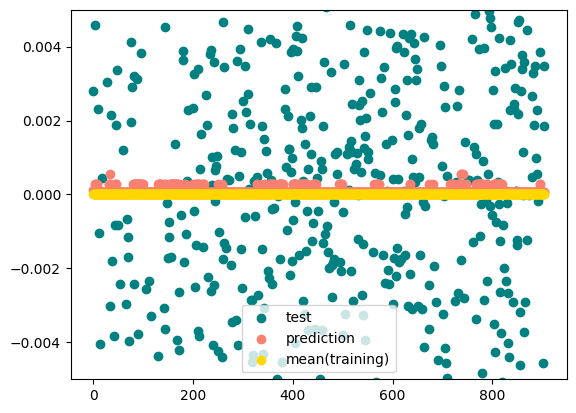

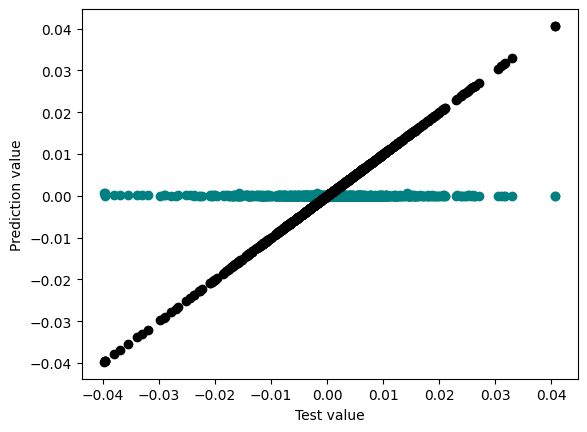

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
naive_pred = np.full_like(y_test, fill_value=y_train.mean())
y_pred = best_hgb.predict(X_test) #Making predictions

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')

plt.legend()
plt.show()
#============ plot with zoom =============0
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')
ax.set_ylim(-0.005,0.005)
plt.legend()
plt.show()
# ============= Plot prediciton vs true
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter( y_test, y_pred, color = 'teal')
ax.scatter( y_test, y_test, color = 'black')
ax.set_xlabel("Test value")
ax.set_ylabel("Prediction value")
plt.show()